<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 150 &middot; Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">From Model to Production (MLOps)</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">A trained model is the start of the job, not the end. We package a model so training and serving cannot drift apart, register a version, serve predictions with input validation, watch for data drift without labels, confirm the damage once labels arrive, and retrain to recover. One machine, no platform, just the moving parts.</div>
</div>

Run top to bottom. Uses **scikit-learn**, **joblib**, **numpy**, **pandas** and **matplotlib**. The dataset is 12 weeks of food-delivery orders; a suburban expansion at week 8 shifts the world the model was trained on, and everything below is about noticing and fixing that.

In [1]:
import numpy as np, pandas as pd, os, json, hashlib, tempfile, joblib
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, recall_score
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD, AM = "#a21caf", "#2563eb", "#16a34a", "#dc2626", "#d97706"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "from-model-to-production-mlops--delivery-orders.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape)
print(df.head(3).to_string())

FEATURES = ["distance_km","prep_time_min","courier_load","order_hour","is_weekend","basket_size"]
TARGET = "late"
TMP = tempfile.gettempdir()   # scratch only; nothing here is written to the book repo

def build_pipeline():
    """Preprocessing AND model in one object, so training and serving cannot diverge."""
    pre = ColumnTransformer([("num", StandardScaler(), FEATURES)])
    return Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=1000))])

(8400, 9)
   order_id  week  distance_km  prep_time_min  courier_load  order_hour  is_weekend  basket_size  late
0         1     1         4.34           15.8             9          12           0        44.36     0
1         2     1         2.68           20.0            11          18           0        35.77     0
2         3     1         4.75           33.0            10          12           0        19.74     1


## DEMO 1 &middot; The artifact: one object for training and serving
The most common production bug is **train/serve skew**: the notebook scales a feature one way, the serving code does it slightly differently, and the model silently sees inputs it was never trained on. The cure is to put every preprocessing step and the model into a single **pipeline**, fit it once, and serialize the whole thing.

We train on weeks 1 to 6, save the pipeline to disk with joblib, reload it, and confirm the reloaded artifact scores raw input identically. Serving never touches a scaler directly.

In [2]:
train = df[df.week <= 6]
pipe = build_pipeline().fit(train[FEATURES], train[TARGET])

path = os.path.join(TMP, "late_model_v1.joblib")
joblib.dump(pipe, path)
print(f"saved artifact: {os.path.getsize(path)/1024:.1f} KB at {path}")

served = joblib.load(path)                          # what production would load
raw = df[df.week == 7][FEATURES]                    # RAW features, no manual scaling
same = np.array_equal(pipe.predict(raw), served.predict(raw))
print("reloaded model gives identical predictions on raw input:", same)
print("\nThe artifact carries the scaler WITH the model, so there is no second code path to keep in sync.")

saved artifact: 2.6 KB at /var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T/late_model_v1.joblib
reloaded model gives identical predictions on raw input: True

The artifact carries the scaler WITH the model, so there is no second code path to keep in sync.


## DEMO 2 &middot; A tiny model registry
Which model is in production, trained on what, scoring how well? In a real stack a registry answers that. Here it is a JSON record: a content hash for the exact artifact, the training window, the feature list, and the validation metrics measured on week 7 (still in-distribution).

The point is not the format, it is the discipline: every deployed model is **versioned and traceable** back to its data and its numbers.

In [3]:
val = df[df.week == 7]
def evaluate(model, d):
    proba = model.predict_proba(d[FEATURES])[:, 1]
    pred = model.predict(d[FEATURES])
    return {"accuracy": round(accuracy_score(d[TARGET], pred), 3),
            "brier": round(brier_score_loss(d[TARGET], proba), 3),
            "recall": round(recall_score(d[TARGET], pred, zero_division=0), 3)}

digest = hashlib.md5(open(path, "rb").read()).hexdigest()[:10]
registry = {"name": "late-delivery-classifier", "version": "v1", "artifact_sha": digest,
            "trained_on": "weeks 1-6", "features": FEATURES,
            "validation_week7": evaluate(pipe, val), "status": "production"}
print(json.dumps(registry, indent=2))

{
  "name": "late-delivery-classifier",
  "version": "v1",
  "artifact_sha": "40b22372d9",
  "trained_on": "weeks 1-6",
  "features": [
    "distance_km",
    "prep_time_min",
    "courier_load",
    "order_hour",
    "is_weekend",
    "basket_size"
  ],
  "validation_week7": {
    "accuracy": 0.727,
    "brier": 0.192,
    "recall": 0.335
  },
  "status": "production"
}


## DEMO 3 &middot; Serving with input validation
A model will happily return a confident number for nonsense: a negative distance, a courier load of 900, a missing column. In production the guard rail is a **schema and range check** at the door, before the model ever sees the row.

The serve function below validates first and only then predicts, returning both the label and the probability so a downstream system can act on the confidence.

In [4]:
RANGES = {"distance_km": (0, 40), "prep_time_min": (0, 90), "courier_load": (0, 60),
          "order_hour": (0, 23), "is_weekend": (0, 1), "basket_size": (0, 500)}

def serve(order: dict, model):
    missing = [f for f in FEATURES if f not in order]
    if missing: return {"error": f"missing features: {missing}"}
    for f, (lo, hi) in RANGES.items():
        if not (lo <= order[f] <= hi): return {"error": f"{f}={order[f]} out of range [{lo}, {hi}]"}
    x = pd.DataFrame([order])[FEATURES]
    p = float(model.predict_proba(x)[0, 1])
    return {"late": int(p >= 0.5), "probability": round(p, 3)}

good = {"distance_km": 8.5, "prep_time_min": 22, "courier_load": 14, "order_hour": 19, "is_weekend": 1, "basket_size": 41}
bad  = {"distance_km": -3,  "prep_time_min": 22, "courier_load": 14, "order_hour": 19, "is_weekend": 1, "basket_size": 41}
print("valid order  ->", serve(good, served))
print("invalid order->", serve(bad, served))

valid order  -> {'late': 1, 'probability': 0.892}
invalid order-> {'error': 'distance_km=-3 out of range [0, 40]'}


## DEMO 4 &middot; Watch the inputs: drift detection without labels
Here is the MLOps insight that saves you. A late-delivery label can take days to arrive, but the **input distribution** is visible the instant an order comes in. If the inputs no longer look like the training data, the model is extrapolating, and you know it before a single label lands.

The **Population Stability Index** measures how far a feature's distribution has moved from a baseline. The rule of thumb: below 0.1 is stable, 0.1 to 0.2 is worth watching, and above 0.2 is a significant shift. We bin on the training baseline and score every production week.

week 7: distance PSI = 0.021
week 8: distance PSI = 0.477  <-- DRIFT
week 9: distance PSI = 0.532  <-- DRIFT
week 10: distance PSI = 0.591  <-- DRIFT
week 11: distance PSI = 0.529  <-- DRIFT
week 12: distance PSI = 0.505  <-- DRIFT


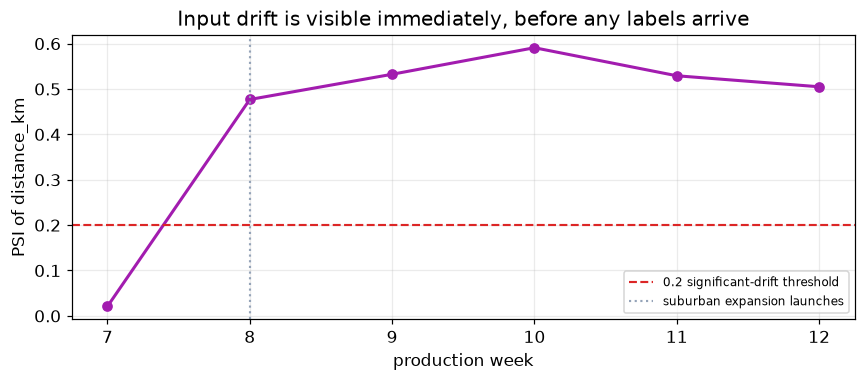


Week 7 is quiet; week 8 jumps past 0.2 the moment the expansion launches.


In [5]:
def psi(baseline, current, bins=10):
    edges = np.quantile(baseline, np.linspace(0, 1, bins + 1)); edges[0], edges[-1] = -np.inf, np.inf
    b = np.clip(np.histogram(baseline, edges)[0] / len(baseline), 1e-4, None)
    c = np.clip(np.histogram(current,  edges)[0] / len(current),  1e-4, None)
    return float(np.sum((c - b) * np.log(c / b)))

baseline = df[df.week <= 6]
weeks = list(range(7, 13))
psi_dist = [psi(baseline.distance_km, df[df.week == w].distance_km) for w in weeks]
for w, v in zip(weeks, psi_dist):
    flag = "  <-- DRIFT" if v > 0.2 else ""
    print(f"week {w}: distance PSI = {v:.3f}{flag}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(weeks, psi_dist, "o-", color=FU, lw=2)
ax.axhline(0.2, color=RD, ls="--", lw=1.4, label="0.2 significant-drift threshold")
ax.axvline(8, color="#94a3b8", ls=":", lw=1.4, label="suburban expansion launches")
ax.set_xlabel("production week"); ax.set_ylabel("PSI of distance_km")
ax.set_title("Input drift is visible immediately, before any labels arrive"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("\nWeek 7 is quiet; week 8 jumps past 0.2 the moment the expansion launches.")

## DEMO 5 &middot; Confirm the damage: performance monitoring
Drift in the inputs is a warning, not a verdict. Once the true late/on-time labels arrive, we can measure what the drift actually cost. We track two numbers weekly: **accuracy**, and the **Brier score**, which measures how well-calibrated the predicted probabilities are (lower is better) and, unlike accuracy or recall, is not flattered when the base rate changes.

Note the honest subtlety in the output: raw recall actually **rises** after the shift, simply because late orders became far more common. That is exactly why you never trust a single headline metric. Accuracy falls and the Brier score worsens, and those are the ones telling the truth.

 week  late_rate  accuracy  brier  recall
    7      0.324     0.727  0.192   0.335
    8      0.677     0.680  0.200   0.637
    9      0.699     0.679  0.203   0.638
   10      0.691     0.716  0.182   0.665
   11      0.671     0.684  0.198   0.634
   12      0.657     0.667  0.202   0.607


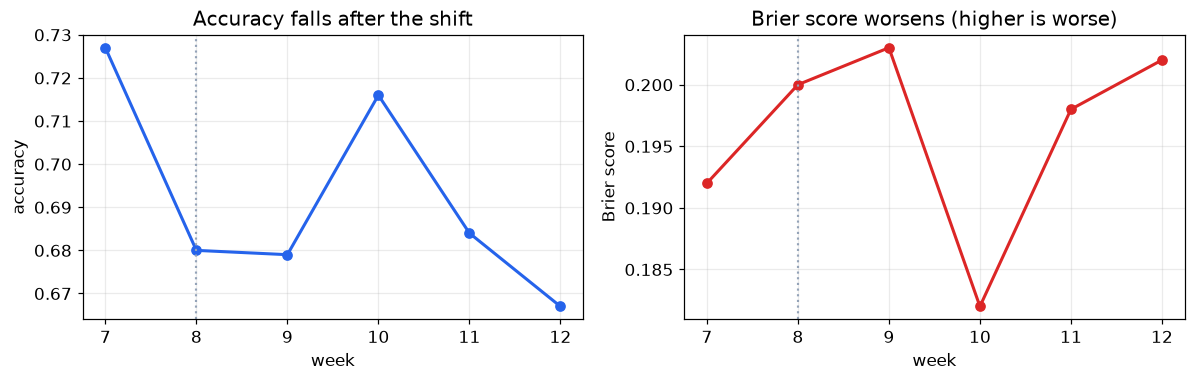

In [6]:
rows = []
for w in weeks:
    d = df[df.week == w]; m = evaluate(pipe, d); m["week"] = w; m["late_rate"] = round(d[TARGET].mean(), 3)
    rows.append(m)
mon = pd.DataFrame(rows)[["week", "late_rate", "accuracy", "brier", "recall"]]
print(mon.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(mon.week, mon.accuracy, "o-", color=BL, lw=2)
ax[0].axvline(8, color="#94a3b8", ls=":", lw=1.4); ax[0].set_title("Accuracy falls after the shift")
ax[0].set_xlabel("week"); ax[0].set_ylabel("accuracy")
ax[1].plot(mon.week, mon.brier, "o-", color=RD, lw=2)
ax[1].axvline(8, color="#94a3b8", ls=":", lw=1.4); ax[1].set_title("Brier score worsens (higher is worse)")
ax[1].set_xlabel("week"); ax[1].set_ylabel("Brier score")
plt.tight_layout(); plt.show()

## DEMO 6 &middot; Close the loop: retrain and recover
Monitoring without a response is just a nicer way to watch a model fail. The last step is the retraining trigger: when drift and degradation persist, refit on **recent** data and compare the challenger against the frozen champion before promoting it.

We retrain on weeks 6 to 9 (spanning the shift) and evaluate both models on the still-unseen weeks 10 to 12. The challenger wins on every metric, so it earns promotion to production as v2.

                                  accuracy  brier  recall
frozen champion (weeks 1-6)          0.689  0.194   0.636
retrained challenger (weeks 6-9)     0.735  0.170   0.831

accuracy 0.689 -> 0.735   brier 0.194 -> 0.170   recall 0.636 -> 0.831


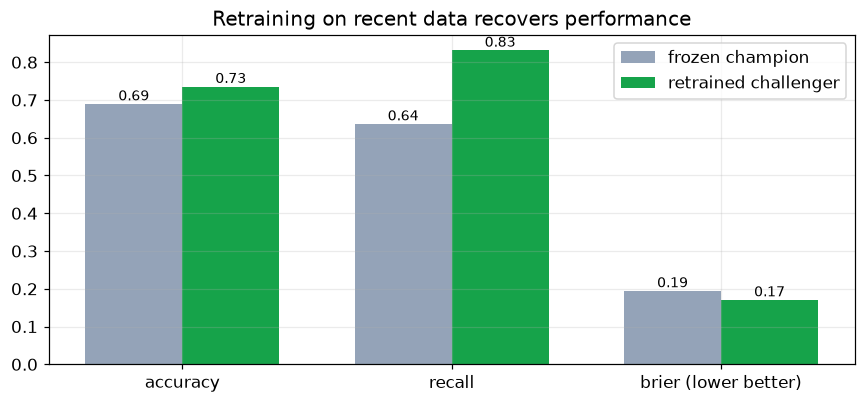

Promote the challenger to v2, archive v1, and keep the monitors running. That loop IS MLOps.


In [7]:
recent = df[(df.week >= 6) & (df.week <= 9)]
challenger = build_pipeline().fit(recent[FEATURES], recent[TARGET])

test = df[df.week >= 10]
champ, chall = evaluate(pipe, test), evaluate(challenger, test)
comp = pd.DataFrame({"frozen champion (weeks 1-6)": champ, "retrained challenger (weeks 6-9)": chall}).T
print(comp.to_string()); print()
print(f"accuracy {champ['accuracy']:.3f} -> {chall['accuracy']:.3f}   "
      f"brier {champ['brier']:.3f} -> {chall['brier']:.3f}   recall {champ['recall']:.3f} -> {chall['recall']:.3f}")

labels = ["accuracy", "recall", "brier (lower better)"]
cv = [champ["accuracy"], champ["recall"], champ["brier"]]
hv = [chall["accuracy"], chall["recall"], chall["brier"]]
x = np.arange(3); w = 0.36
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - w/2, cv, w, label="frozen champion", color="#94a3b8")
ax.bar(x + w/2, hv, w, label="retrained challenger", color=GR)
ax.set_xticks(x, labels); ax.set_title("Retraining on recent data recovers performance"); ax.legend()
for i, (a, b) in enumerate(zip(cv, hv)):
    ax.text(i - w/2, a + .01, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, b + .01, f"{b:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Promote the challenger to v2, archive v1, and keep the monitors running. That loop IS MLOps.")

### Wrap-up
Six moving parts, one machine, no platform. We packaged preprocessing and model into a single artifact so serving cannot skew from training, registered it with a hash and its metrics, served predictions behind an input-validation gate, detected the week-8 shift from the **inputs alone** before any labels arrived, confirmed the cost with accuracy and a calibration score once labels came back, and retrained to recover, promoting the challenger only after it beat the champion on held-out weeks.

A production platform (MLflow, SageMaker, Vertex, a feature store, a CI/CD pipeline) automates every one of these steps, but it does not add a step. If you can package, register, serve, monitor, and retrain by hand, you understand what the platform is doing for you. This chapter closes Part XXIV, Advanced & Applied Topics.